# Flow-Based Market Coupling — Analysis Notebook

Security-constrained FBMC on a 3-zone, 4-bus test network.

In [1]:
import pypsa
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx

from fbmc import nodal_to_zonal
from fbmc.api import run_fbmc
from fbmc.settings import FBMCConfig
from fbmc.enums import BaseCaseStrategy, GSKStrategy

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

## Network & config

In [2]:
snapshots = ['t1', 't2']
load_A = [10, 30]
load_B = [10, 40]
load_C = [5, 45]

nodal_net = pypsa.Network()
nodal_net.set_snapshots(snapshots)

nodal_net.add('Bus', ['A1', 'B1', 'B2', 'C1'])
nodal_net.buses.loc[:, 'zone_name'] = ['A', 'B', 'B', 'C']

for name, b0, b1, x, s_nom in [
    ('A1-B1', 'A1', 'B1', 1.0, 15),
    ('A1-B2', 'A1', 'B2', 1.5, 18),
    ('B1-B2', 'B1', 'B2', 0.5, 15),
    ('B1-C1', 'B1', 'C1', 1.0, 12),
    ('B2-C1', 'B2', 'C1', 1.5, 18),
]:
    nodal_net.add('Line', name, bus0=b0, bus1=b1, x=x, s_nom=s_nom)

nodal_net.add('Generator', 'gen_A_oil',  bus='A1', p_nom=60, marginal_cost=400, carrier='Oil')
nodal_net.add('Generator', 'gen_B_wind', bus='B1', p_nom=50, marginal_cost=20,  carrier='Wind')
nodal_net.add('Generator', 'gen_B_ccgt', bus='B2', p_nom=60, marginal_cost=150, carrier='CCGT')
nodal_net.add('Generator', 'gen_C_coal', bus='C1', p_nom=50, marginal_cost=250, carrier='Coal')

nodal_net.add('Load', 'load_A1', bus='A1', p_set=load_A)
nodal_net.add('Load', 'load_B1', bus='B1', p_set=load_B)
nodal_net.add('Load', 'load_C1', bus='C1', p_set=load_C)

bus_zone_map = nodal_net.buses['zone_name']
zonal_net = nodal_to_zonal(nodal_net.copy(), bus_zone_map=bus_zone_map)

In [3]:
config = FBMCConfig(
    base_case_strategy=BaseCaseStrategy.SECURITY_CONSTRAINED_NODAL_OPTIMUM,
    add_security_constraints=True,
    gsk_strategy=GSKStrategy.P_NOM,
    security_constraint_bodf_size_threshold=0.1,
    solver_kwargs={'solver_name': 'gurobi', 'OutputFlag': 0},
)

result = run_fbmc(zonal_net=zonal_net, nodal_net=nodal_net, config=config)
print(result)

Index(['A1', 'B1', 'B2', 'C1'], dtype='object', name='Bus')
Index(['0'], dtype='object', name='SubNetwork')
Index(['gen_A_oil', 'gen_B_wind', 'gen_B_ccgt', 'gen_C_coal'], dtype='object', name='Generator')
Index(['A1-B1', 'A1-B2', 'B1-B2', 'B1-C1', 'B2-C1'], dtype='object', name='Line')
Index(['A1-B1', 'A1-B2', 'B1-B2', 'B1-C1', 'B2-C1'], dtype='object', name='Line')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - OutputFlag: 0
INFO:linopy.io: Writing time: 0.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2027-01-07


INFO:gurobipy:Academic license - for non-commercial use only - expires 2027-01-07


...

Reading time = 0.00 seconds


INFO:gurobipy:Reading time = 0.00 seconds


obj: 104 rows, 14 columns, 188 nonzeros


INFO:gurobipy:obj: 104 rows, 14 columns, 188 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 14 primals, 104 duals
Objective: 1.83e+04
Solver model: available
Solver message: 2



FBMCResult
  zonal_net: Unnamed Network | snapshots=2 | components=[Bus:3, Generator:4, Load:3]
  base_case: Unnamed Network | snapshots=2 | components=[Bus:4, Generator:4, Load:3, Line:5, SubNetwork:1]
  net_positions: DataFrame(2, 3)
  dispatch_results: DispatchResult object with attrs: 
  generators_p: (2, 4) snapshots x generators, 
  storage_units_p: (2, 0) snapshots x storage units, 
  links_p0: (2, 0) snapshots x links, 
  storage_levels: None snapshots x storage levels, 
  water_values: None snapshots x water values
  fbmc_parameters: 1 subnet(s) [0]


In [4]:
result.zonal_net.model.constraints['CNEC-upper-RAM-subnet-0'].sel(snapshot='t1')

Constraint `CNEC-upper-RAM-subnet-0` [cnec: 20]:
------------------------------------------------
[0]: -1 Zone-p[t1, B] - 1 Zone-p[t1, C]             ≤ 14.999999999999996
[1]: -0.5273 Zone-p[t1, B] - 0.6 Zone-p[t1, C]      ≤ 19.090909090909093
[2]: -0.5758 Zone-p[t1, B] - 0.5 Zone-p[t1, C]      ≤ 16.363636363636367
[3]: -0.5758 Zone-p[t1, B] - 0.6667 Zone-p[t1, C]   ≤ 16.363636363636367
[4]: -1 Zone-p[t1, B] - 1 Zone-p[t1, C]             ≤ 17.999999999999996
[5]: -0.4727 Zone-p[t1, B] - 0.4 Zone-p[t1, C]      ≤ 13.909090909090907
[6]: -0.4242 Zone-p[t1, B] - 0.5 Zone-p[t1, C]      ≤ 16.636363636363637
		...
[13]: -0.09091 Zone-p[t1, B] - 0.6667 Zone-p[t1, C] ≤ 10.636363636363637
[14]: -0.07273 Zone-p[t1, B] - 0.6 Zone-p[t1, C]    ≤ 7.9090909090909065
[15]: -1 Zone-p[t1, C]                              ≤ 12.0
[16]: -0.07576 Zone-p[t1, B] - 0.5 Zone-p[t1, C]    ≤ 19.363636363636363
[17]: +0.09091 Zone-p[t1, B] - 0.3333 Zone-p[t1, C] ≤ 19.363636363636363
[18]: +0.07273 Zone-p[t1, B] - 0.4

In [5]:
result.fbmc_parameters['0'].cnecs.outage.to_pandas()

branch  outage
A1-B1   A1-B2     A1-B2
        B1-B2     B1-B2
        B1-C1     B1-C1
        B2-C1     B2-C1
A1-B2   A1-B1     A1-B1
        B1-B2     B1-B2
        B1-C1     B1-C1
        B2-C1     B2-C1
B1-B2   A1-B1     A1-B1
        A1-B2     A1-B2
        B1-C1     B1-C1
        B2-C1     B2-C1
B1-C1   A1-B1     A1-B1
        A1-B2     A1-B2
        B1-B2     B1-B2
        B2-C1     B2-C1
B2-C1   A1-B1     A1-B1
        A1-B2     A1-B2
        B1-B2     B1-B2
        B1-C1     B1-C1
Name: outage, dtype: object

## Input data

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


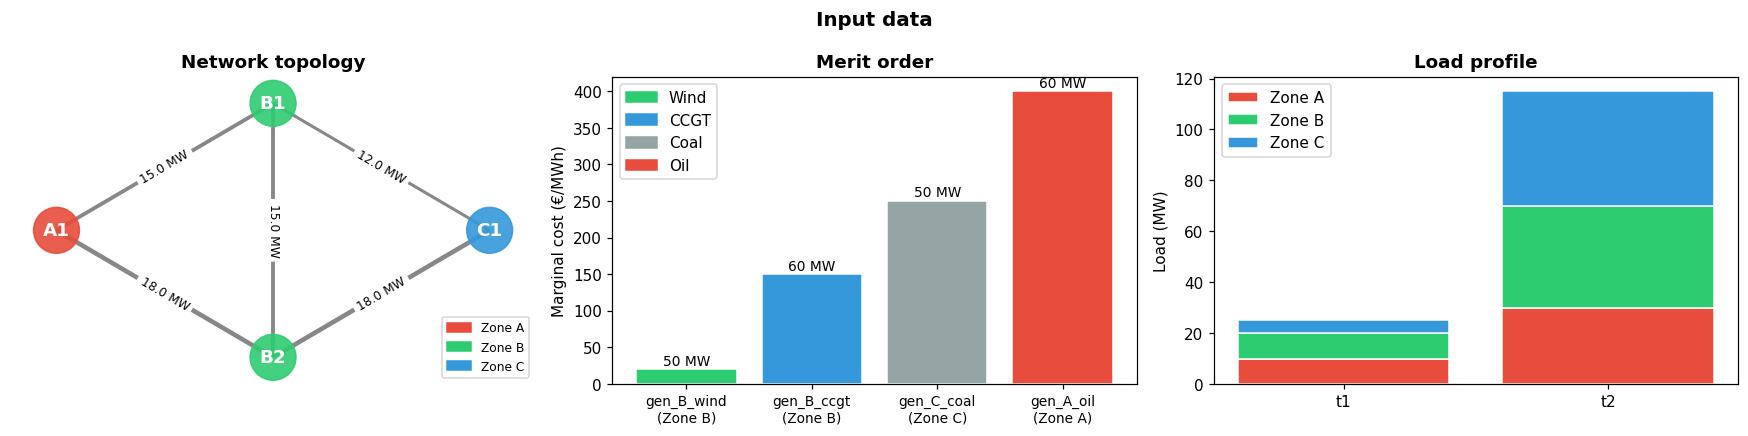

In [6]:
zone_colors   = {'A': '#E74C3C', 'B': '#2ECC71', 'C': '#3498DB'}
carrier_colors = {'Wind': '#2ECC71', 'CCGT': '#3498DB', 'Coal': '#95A5A6', 'Oil': '#E74C3C'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Network topology
ax = axes[0]
pos = {'A1': (-2, 0), 'B1': (0, 1.2), 'B2': (0, -1.2), 'C1': (2, 0)}
G = nx.Graph()
G.add_nodes_from(nodal_net.buses.index)
for l in nodal_net.lines.itertuples():
    G.add_edge(l.bus0, l.bus1, s_nom=l.s_nom)

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[zone_colors[nodal_net.buses.loc[b, 'zone_name']] for b in G.nodes()],
    node_size=900, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, ax=ax,
    width=[G[u][v]['s_nom'] / 6 for u, v in G.edges()], edge_color='#555', alpha=0.7)
nx.draw_networkx_edge_labels(G, pos,
    {(u, v): f"{G[u][v]['s_nom']} MW" for u, v in G.edges()}, font_size=8, ax=ax)
ax.legend(handles=[mpatches.Patch(color=c, label=f'Zone {z}') for z, c in zone_colors.items()],
          loc='lower right', fontsize=8)
ax.set_title('Network topology', fontweight='bold')
ax.axis('off')

# Merit order
ax = axes[1]
gens = nodal_net.generators.copy()
gens['zone'] = nodal_net.buses.loc[gens['bus'], 'zone_name'].values
gens = gens.sort_values('marginal_cost')
ax.bar(range(len(gens)), gens['marginal_cost'],
       color=[carrier_colors[c] for c in gens['carrier']], edgecolor='white')
for i, (_, row) in enumerate(gens.iterrows()):
    ax.text(i, row['marginal_cost'] + 6, f"{int(row['p_nom'])} MW", ha='center', fontsize=9)
ax.set_xticks(range(len(gens)))
ax.set_xticklabels([f"{idx}\n(Zone {row['zone']})" for idx, row in gens.iterrows()], fontsize=9)
ax.set_ylabel('Marginal cost (€/MWh)')
ax.set_title('Merit order', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=carrier_colors[c], label=c) for c in gens['carrier'].unique()])

# Load profile
ax = axes[2]
loads_df = pd.DataFrame({'Zone A': load_A, 'Zone B': load_B, 'Zone C': load_C}, index=snapshots)
bottom = np.zeros(len(snapshots))
for zone, col in [('A', 'Zone A'), ('B', 'Zone B'), ('C', 'Zone C')]:
    ax.bar(snapshots, loads_df[col], bottom=bottom,
           color=zone_colors[zone], label=col, edgecolor='white')
    bottom += loads_df[col].values
ax.set_ylabel('Load (MW)')
ax.set_title('Load profile', fontweight='bold')
ax.legend()

plt.suptitle('Input data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Flow-based domain

3 zones → balance constraint NP_A + NP_B + NP_C = 0 → 2D feasible space.  
Each CNEC constraint in (NP_A, NP_B) coordinates: `(ptdf_A − ptdf_C)·NP_A + (ptdf_B − ptdf_C)·NP_B ≤ RAM`.

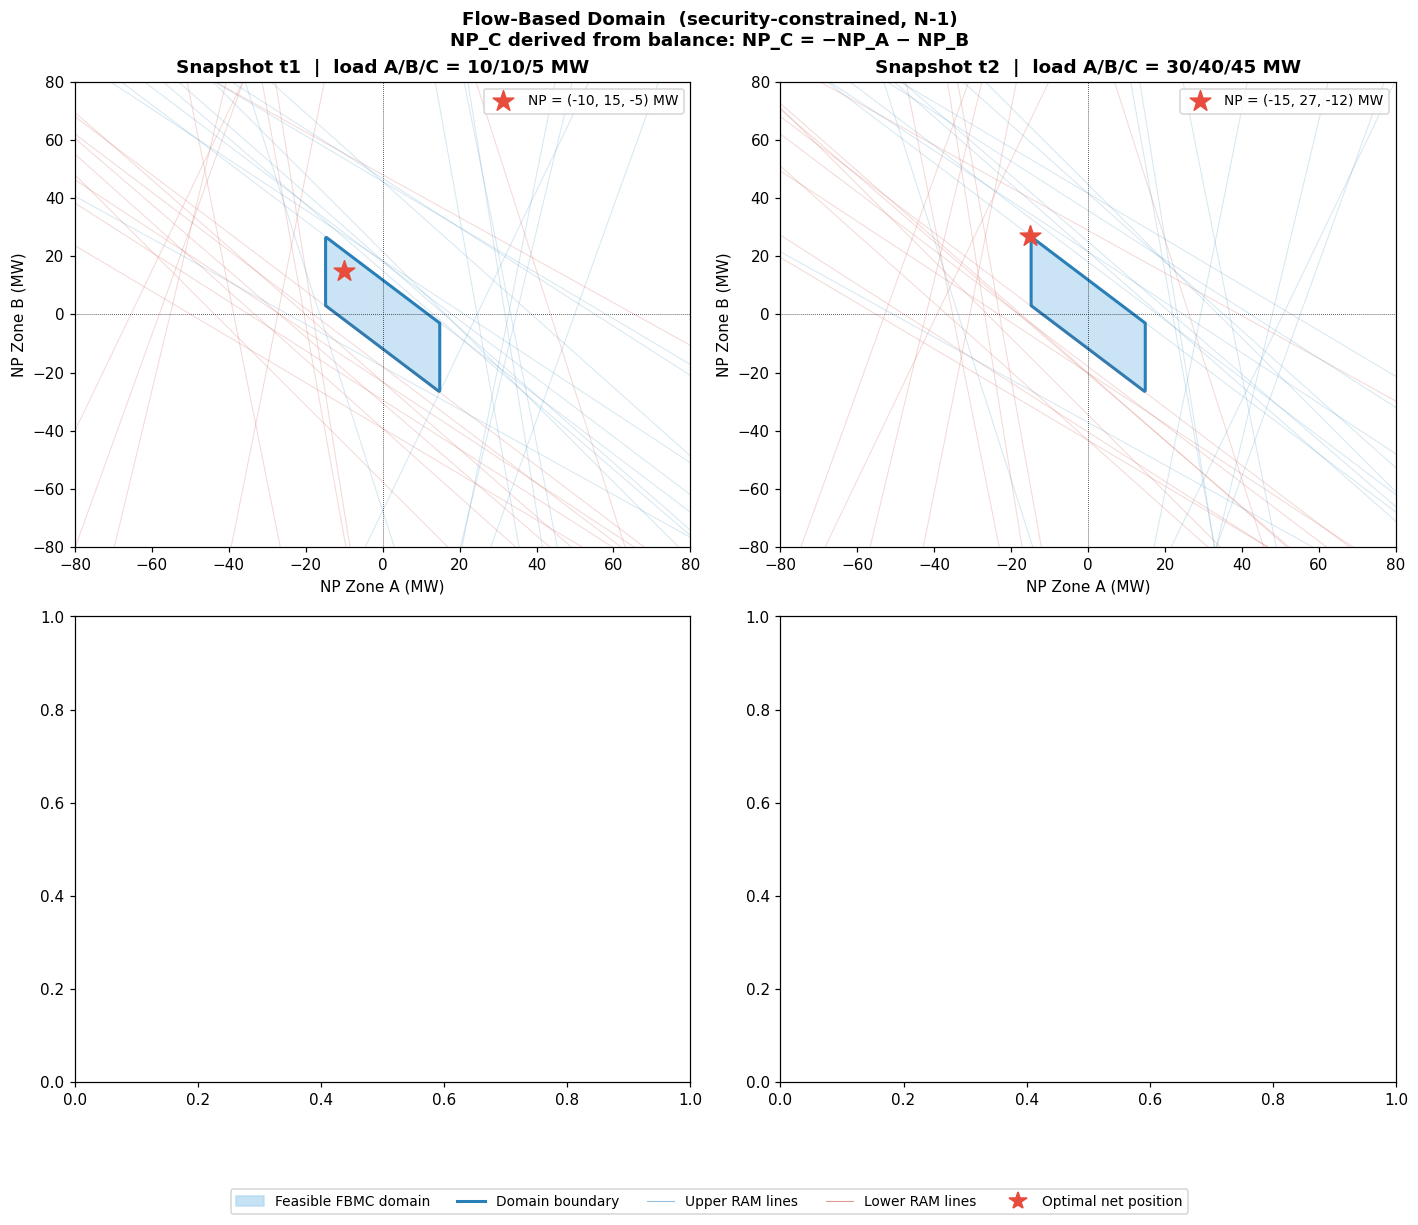

In [7]:
params    = result.fbmc_parameters['0']
z_ptdf    = params.z_ptdf
upper_ram = params.upper_ram
lower_ram = params.lower_ram
zones     = list(params.zones)
zone_x, zone_y, zone_ref = zones[0], zones[1], zones[2]   # A, B, C

net_pos = result.net_positions  # xr.DataArray (snapshot, Zone)

plot_range = 80.0
NP_range   = np.linspace(-plot_range, plot_range, 400)
NP_A_grid, NP_B_grid = np.meshgrid(NP_range, NP_range)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for i, snap in enumerate(snapshots):
    ax = axes[i]

    z_snap = z_ptdf.sel(snapshot=snap) if 'snapshot' in z_ptdf.dims else z_ptdf
    ptdf_x = (z_snap.sel(Zone=zone_x) - z_snap.sel(Zone=zone_ref)).values
    ptdf_y = (z_snap.sel(Zone=zone_y) - z_snap.sel(Zone=zone_ref)).values

    u_ram = upper_ram.sel(snapshot=snap).values if 'snapshot' in upper_ram.dims else upper_ram.values
    l_ram = lower_ram.sel(snapshot=snap).values if 'snapshot' in lower_ram.dims else lower_ram.values

    # Feasible region: shape (n_cnec, 400, 400) → reduce over cnec axis
    flow_grid = ptdf_x[:, None, None] * NP_A_grid[None] + ptdf_y[:, None, None] * NP_B_grid[None]
    feasible = np.all(
        (flow_grid <= u_ram[:, None, None] + 1e-3) &
        (flow_grid >= l_ram[:, None, None] - 1e-3),
        axis=0,
    )

    ax.contourf(NP_A_grid, NP_B_grid, feasible.astype(float),
                levels=[0.5, 1.5], colors=['#AED6F1'], alpha=0.65)
    ax.contour(NP_A_grid, NP_B_grid, feasible.astype(float),
               levels=[0.5], colors=['#2980B9'], linewidths=2.0)

    # Individual CNEC lines (thin)
    for c in range(len(u_ram)):
        if abs(ptdf_y[c]) > 1e-3:
            ax.plot(NP_range, (u_ram[c] - ptdf_x[c] * NP_range) / ptdf_y[c],
                    color='#2980B9', alpha=0.18, lw=0.7)
            ax.plot(NP_range, (l_ram[c] - ptdf_x[c] * NP_range) / ptdf_y[c],
                    color='#C0392B', alpha=0.18, lw=0.7)

    # Optimal net position
    np_a = float(net_pos.sel(snapshot=snap, Zone=zone_x))
    np_b = float(net_pos.sel(snapshot=snap, Zone=zone_y))
    np_c = float(net_pos.sel(snapshot=snap, Zone=zone_ref))
    ax.scatter(np_a, np_b, color='#E74C3C', s=200, zorder=6, marker='*',
               label=f'NP = ({np_a:.0f}, {np_b:.0f}, {np_c:.0f}) MW')

    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    ax.set_xlabel(f'NP Zone {zone_x} (MW)')
    ax.set_ylabel(f'NP Zone {zone_y} (MW)')
    ax.set_title(
        f'Snapshot {snap}  |  load A/B/C = {load_A[i]}/{load_B[i]}/{load_C[i]} MW',
        fontweight='bold'
    )
    ax.legend(fontsize=9, loc='upper right')

fig.legend(handles=[
    mpatches.Patch(color='#AED6F1', alpha=0.7, label='Feasible FBMC domain'),
    Line2D([0], [0], color='#2980B9', lw=2,   label='Domain boundary'),
    Line2D([0], [0], color='#2980B9', lw=0.7, alpha=0.5, label='Upper RAM lines'),
    Line2D([0], [0], color='#C0392B', lw=0.7, alpha=0.5, label='Lower RAM lines'),
    Line2D([0], [0], color='#E74C3C', marker='*', ms=12, lw=0, label='Optimal net position'),
], loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle(
    'Flow-Based Domain  (security-constrained, N-1)\n'
    f'NP_{zone_ref} derived from balance: NP_{zone_ref} = −NP_{zone_x} − NP_{zone_y}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## zPTDF matrix

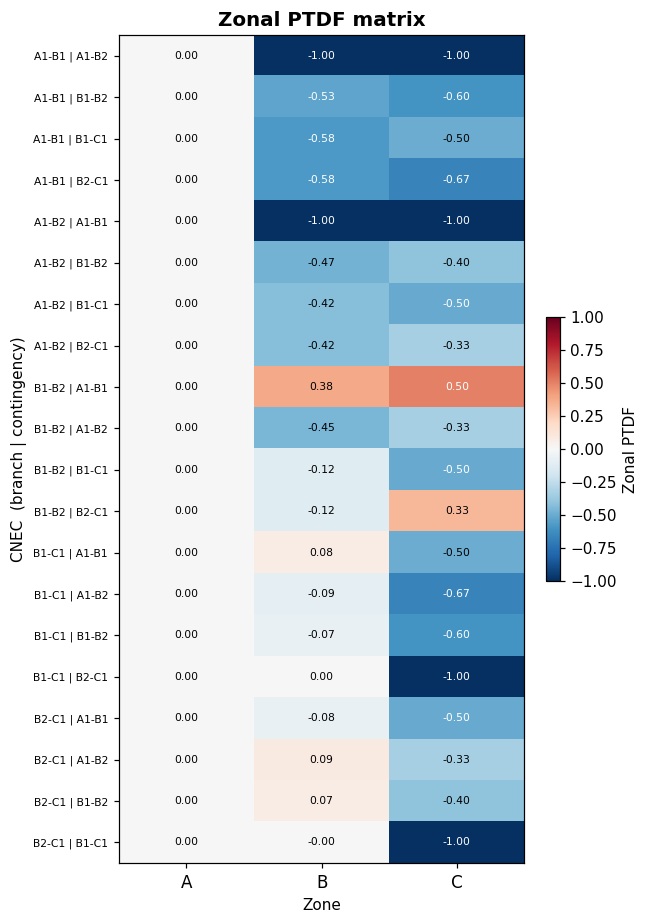

In [8]:
z_ptdf_2d = z_ptdf.isel(snapshot=0) if 'snapshot' in z_ptdf.dims else z_ptdf
ptdf_values = z_ptdf_2d.values  # (cnec, zone)

branch_vals = z_ptdf_2d.coords['branch'].values
if 'outage' in z_ptdf_2d.coords:
    cnec_labels = [f"{b} | {o}" for b, o in zip(branch_vals, z_ptdf_2d.coords['outage'].values)]
else:
    cnec_labels = list(branch_vals)

n_cnec = len(cnec_labels)
fig, ax = plt.subplots(figsize=(6, max(4, n_cnec * 0.35 + 1.5)))

im = ax.imshow(ptdf_values.T, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(zones)))
ax.set_xticklabels(zones, fontsize=11)
ax.set_yticks(range(n_cnec))
ax.set_yticklabels(cnec_labels, fontsize=7)

for ci in range(n_cnec):
    for zi in range(len(zones)):
        v = ptdf_values.T[ci, zi]
        ax.text(zi, ci, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.5 else 'black')

plt.colorbar(im, ax=ax, fraction=0.03, label='Zonal PTDF')
ax.set_xlabel('Zone')
ax.set_ylabel('CNEC  (branch | contingency)')
ax.set_title('Zonal PTDF matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Dispatch results

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

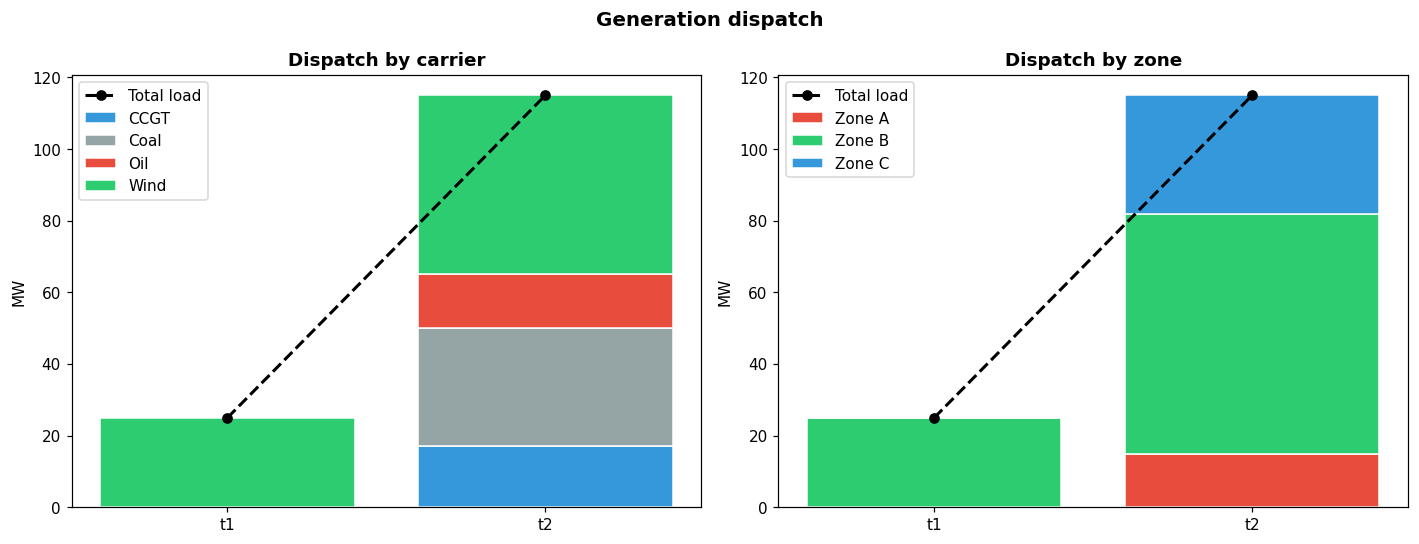

In [9]:
generators_p = result.dispatch_results.generators_p
carriers     = nodal_net.generators['carrier']
gen_zones    = nodal_net.buses.loc[nodal_net.generators['bus'], 'zone_name']
gen_zones.index = nodal_net.generators.index

dispatch_by_carrier = generators_p.T.assign(carrier=carriers).groupby('carrier').sum().T
dispatch_by_carrier.index = snapshots

dispatch_by_zone = generators_p.T.assign(zone=gen_zones).groupby('zone').sum().T
dispatch_by_zone.index = snapshots

total_load = [a + b + c for a, b, c in zip(load_A, load_B, load_C)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dispatch by carrier
ax = axes[0]
bottom = np.zeros(len(snapshots))
for carrier in dispatch_by_carrier.columns:
    vals = dispatch_by_carrier[carrier].values
    ax.bar(snapshots, vals, bottom=bottom,
           color=carrier_colors.get(carrier, '#999'), label=carrier, edgecolor='white')
    bottom += vals
ax.plot(snapshots, total_load, 'k--o', lw=2, label='Total load', zorder=5)
ax.set_ylabel('MW')
ax.set_title('Dispatch by carrier', fontweight='bold')
ax.legend()

# Dispatch by zone
ax = axes[1]
bottom = np.zeros(len(snapshots))
for zone in sorted(dispatch_by_zone.columns):
    vals = dispatch_by_zone[zone].values
    ax.bar(snapshots, vals, bottom=bottom,
           color=zone_colors.get(zone, '#999'), label=f'Zone {zone}', edgecolor='white')
    bottom += vals
ax.plot(snapshots, total_load, 'k--o', lw=2, label='Total load', zorder=5)
ax.set_ylabel('MW')
ax.set_title('Dispatch by zone', fontweight='bold')
ax.legend()

plt.suptitle('Generation dispatch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Net positions

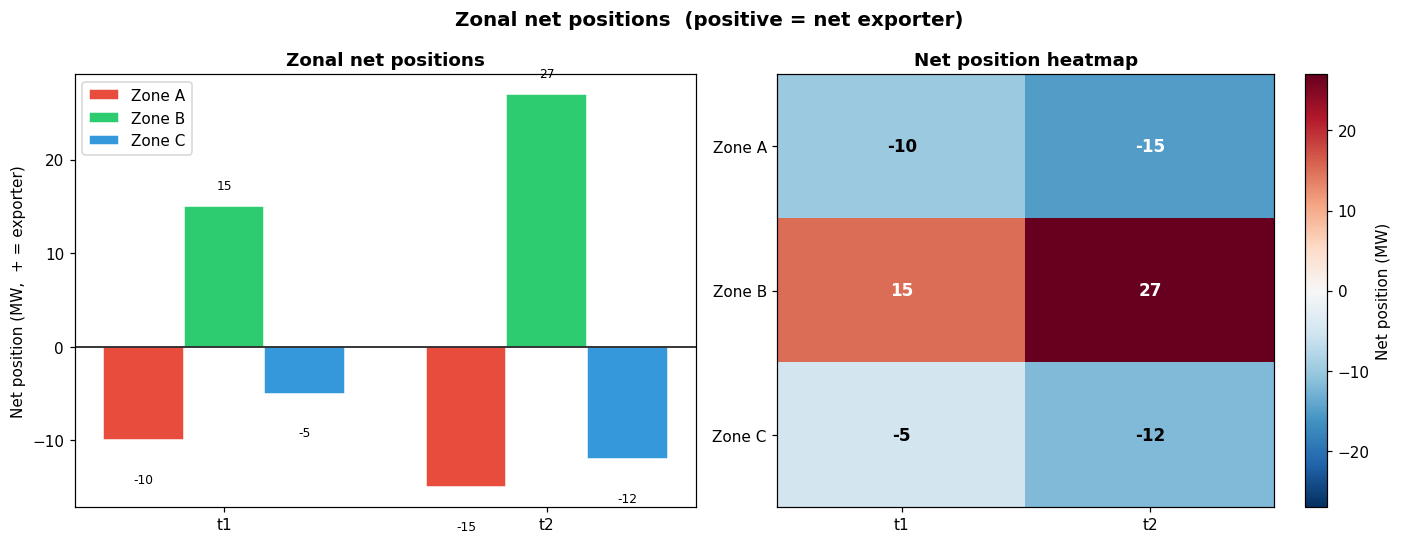

In [10]:
net_pos_df = pd.DataFrame(
    net_pos.values,
    index=net_pos.coords['snapshot'].values,
    columns=net_pos.coords['Zone'].values,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar
ax = axes[0]
x = np.arange(len(snapshots))
w = 0.25
for j, zone in enumerate(sorted(net_pos_df.columns)):
    bars = ax.bar(x + j * w, net_pos_df[zone], w,
                  color=zone_colors.get(zone, '#999'), label=f'Zone {zone}', edgecolor='white')
    for bar, v in zip(bars, net_pos_df[zone]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (1.5 if v >= 0 else -3.5), f'{v:.0f}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax.axhline(0, color='k', lw=1)
ax.set_xticks(x + w)
ax.set_xticklabels(snapshots)
ax.set_ylabel('Net position (MW,  + = exporter)')
ax.set_title('Zonal net positions', fontweight='bold')
ax.legend()

# Heatmap
ax = axes[1]
sorted_zones = sorted(net_pos_df.columns)
data = net_pos_df[sorted_zones].T.values
vmax = np.abs(data).max()
im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(snapshots)))
ax.set_xticklabels(snapshots)
ax.set_yticks(range(len(sorted_zones)))
ax.set_yticklabels([f'Zone {z}' for z in sorted_zones])
for zi, zone in enumerate(sorted_zones):
    for si, snap in enumerate(snapshots):
        v = net_pos_df.loc[snap, zone]
        ax.text(si, zi, f'{v:.0f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if abs(v) > vmax * 0.45 else 'black')
plt.colorbar(im, ax=ax, label='Net position (MW)')
ax.set_title('Net position heatmap', fontweight='bold')

plt.suptitle('Zonal net positions  (positive = net exporter)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
bc = result.base_case

In [12]:
bc.generators_t.p_set = result.dispatch_results.generators_p

In [13]:
bc.generators_t.p

Generator,gen_A_oil,gen_B_wind,gen_B_ccgt,gen_C_coal
snapshot,,,,
t1,0.0,25.0,0.0,0.0
t2,15.0,50.0,17.0,33.0


In [14]:
bc.lpf_contingency(snapshots=[bc.snapshots[0]], branch_outages=bc.lines.index)

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x0000024113A9A7D0> for snapshot(s) Index(['t1'], dtype='object', name='snapshot')


base  (Line, A1-B1)  (Line, A1-B2)  (Line, B1-B2)  \
Line A1-B1 -6.857143   0.000000e+00     -10.000000           -9.0   
     A1-B2 -3.142857  -1.000000e+01       0.000000           -1.0   
     B1-B2  4.285714   1.000000e+01       1.666667            0.0   
     B1-C1  3.857143   5.000000e+00       3.333333            6.0   
     B2-C1  1.142857  -4.440892e-16       1.666667           -1.0   

            (Line, B1-C1)  (Line, B2-C1)  
Line A1-B1           -7.5      -6.666667  
     A1-B2           -2.5      -3.333333  
     B1-B2            7.5       3.333333  
     B1-C1            0.0       5.000000  
     B2-C1            5.0       0.000000

In [15]:
(bc.lines_t.p0.abs() > bc.lines.s_nom).sum()

A1-B1    0
A1-B2    0
B1-B2    0
B1-C1    0
B2-C1    0
dtype: int64